In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.hamiltonian import Lattice, Hamiltonian
from scripts.self_consistency import bdg_sc

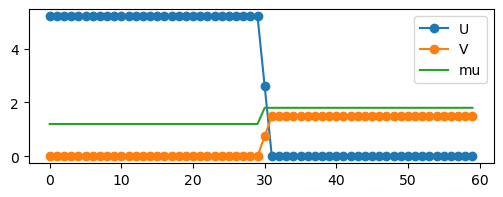

In [2]:
widthN = 30
widthP = 30
X, Y = widthN+widthP, 61
lattice = Lattice(X, Y)

t = 1
T = 0.01

muN = 1.2 * t
muP = 1.8 * t
mu = np.zeros(lattice.X)
mu[:widthN:] = muN
mu[widthN:] = muP

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthN:] = 0
U[widthN] = U0/2

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[:widthN] = 0 
V[widthN] = V0/2 

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, label='mu')
plt.legend()

In [3]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j], F0_init=0.1)

d:\miniconda3\envs\master-venv\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\miniconda3\envs\master-venv\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


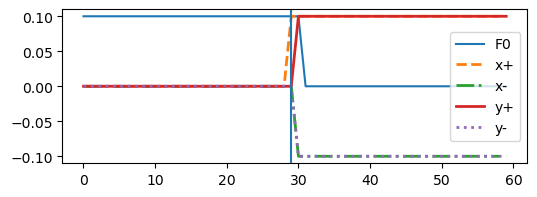

In [4]:
plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.Fuu_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.Fuu_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthN-1)

In [5]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=500, verbose=True, temperature=T)


F0:
Absolute error: 1.5632482331666735
Relative error: 73301321105.66466
Average old: (0.05166666666666666+0j)
Average: (0.19798967523477978+0j)
F_xplus:
Absolute error: 0.36404009684883487
Relative error: 311344613167.35516
Average old: (0.05084745762711865+0j)
Average: (0.0301714195473621+0j)
F_xmin:
Absolute error: 0.3703872145362146
Relative error: 345144423782.59143
Average old: (-0.04915254237288135+0j)
Average: (-0.092279119900549+0j)
F_yplus:
Absolute error: 0.3965410657849894
Relative error: 357895549502.76
Average old: 0.05j
Average: (-0.034893763284427545+0.06214223690738154j)
F_ymin:
Absolute error: 0.3965410657849894
Relative error: 357895549502.76
Average old: -0.05j
Average: (-0.034893763284427545-0.06214223690738154j)
Fuu_xplus:
Absolute error: 4.8730274036423006e-17
Relative error: 4.8730274036423005e-05
Average old: 0j
Average: (-6.68990933208356e-19+0j)
Fuu_xmin:
Absolute error: 5.355351461460482e-17
Relative error: 5.3553514614604816e-05
Average old: 0j
Average: (6.

In [6]:
F_yplus = H.Fuu_yplus + H.Fdd_yplus 
F_ymin = H.Fuu_ymin + H.Fdd_ymin
F_xplus = np.zeros_like(F_yplus)
F_xmin = np.zeros_like(F_yplus)
F_xplus[:-1] = H.Fuu_xplus + H.Fdd_xplus
F_xmin[1:]  = H.Fuu_xmin + H.Fdd_xmin

F0 = H.F0

F_swave2 = (F_xplus + F_xmin + F_yplus + F_ymin) / 4
F_dwave2 = (F_xplus + F_xmin - F_yplus - F_ymin) / 4
F_px2 = (F_xplus - F_xmin) / 2
F_py2 = (F_yplus - F_ymin) / 2

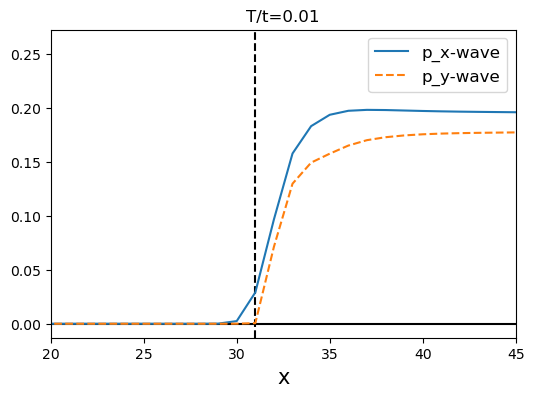

In [10]:
x = np.arange(1, widthN + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(6, 4))
axs.set_title(f"T/t={T}")
# axs.plot(x, np.real(F_swave), label="s-wave")
# axs.plot(x, np.real(-F_dwave), '--', label="d-wave")
axs.axhline(0, color = 'black')
axs.axvline(widthN+1, color='black', linestyle='--')
axs.plot(x, np.real(F_px), label="p_x-wave")
axs.plot(x, np.imag(F_py), "--", label="p_y-wave")
axs.set_xlabel("x", fontsize=15)
axs.set_xlim(20, 45)
# axs.set_ylim(0, None)
axs.legend(fontsize=12, loc="best")
plt.savefig("../figures/SP.pdf")
plt.show()